In [25]:
pd.set_option('display.max_columns', None)
import pandas as pd

pd.set_option('display.max_rows', None)        # show all rows
pd.set_option('display.max_columns', None)     # show all columns
pd.set_option('display.width', None)           # auto-detect width
pd.set_option('display.max_colwidth', None)    # show full text in each cell

# 0 LOAD modules 

In [26]:
# from src.data_loader_pkl import load_pkl_folder

# from src.data_loader_pkl import EDA_check_paths


# # from src.eda import eda_01_06_GET_report
# # from src.preprocessing import prep_features_target
# # from src.modeling import split_train_test
import pandas as pd
import os

# 1 # LOAD DATA 

In [27]:
path_name = '/Users/yerik/_apple_lib/_a_progs/_a2ms_env/_9_ML_project/data/processed/df_03_27_2026_aiff_tracks_data.pkl'

df= pd.read_pickle(path_name)

print(len(df))
# check if paths exist 
print(df['Path'].apply(lambda x: os.path.exists(x)).all())

2402
True


# KEEP NEEDED VARIABLES

In [28]:
cols_keep =  ['ID', 'Path', 'ms_lufs',  'id_cat_lufs','ms_LUFS_norm','lufs_pct',
              'bpm_consistency','bpm_consistency_cat',
              'genre', 'rel_year', 'KEY',
               'key_file', 'remix', 'key_dj', 'key_music', 'Relative_Key',
              'Key_Up','Key_Down','Jaw_s_Mix', 'Mood_Shifter','Spectral_Bandwidth', 'Spectral_Flatness',
              'HEX_shape_texture', 'spec_centroid_hz','centroid_color','centroid_desc']
df = df[[c for c in cols_keep if c in df.columns]]

In [29]:
df.isna().sum().sort_values(ascending=False).head(120)

rel_year               187
genre                  139
ID                       0
key_music                0
centroid_color           0
spec_centroid_hz         0
HEX_shape_texture        0
Spectral_Flatness        0
Spectral_Bandwidth       0
Mood_Shifter             0
Jaw_s_Mix                0
Key_Down                 0
Key_Up                   0
Relative_Key             0
key_dj                   0
Path                     0
remix                    0
key_file                 0
KEY                      0
bpm_consistency_cat      0
bpm_consistency          0
lufs_pct                 0
ms_LUFS_norm             0
id_cat_lufs              0
ms_lufs                  0
centroid_desc            0
dtype: int64

# EDA 

In [30]:
# ---------------------------------
# COLUMN PROFILE + CLEAN CATEGORY VALUES
# ---------------------------------

import pandas as pd
import numpy as np

# ---------------------------------
# BASE SUMMARY
# ---------------------------------
summary = pd.DataFrame({
    'missing_count' : df.isna().sum(),
    'dtype'         : df.dtypes.astype(str),
    'n_unique'      : df.nunique(dropna=True)
})

# ---------------------------------
# FLAGS
# ---------------------------------
summary['is_categorical'] = np.where(
    (summary['dtype'] == 'object') | (summary['n_unique'] < 20),
    True, False
)

summary['is_id'] = np.where(
    (summary['n_unique'] == len(df)) & (summary['missing_count'] == 0),
    True, False
)

# detect path-like columns
summary['is_path'] = summary.index.str.lower().str.contains('path')

# ---------------------------------
# NUMERICAL STATS
# ---------------------------------
num_cols = df.select_dtypes(include=np.number).columns

summary['mean'] = df[num_cols].mean()
summary['min']  = df[num_cols].min()
summary['max']  = df[num_cols].max()

# ---------------------------------
# CATEGORY VALUES (EXCLUDE ID + PATH)
# ---------------------------------
def get_cat_values(col):
    vals = sorted(col.dropna().unique())
    return " | ".join([str(v) for v in vals])

summary['cat_values'] = None

cat_cols = summary[
    (summary['is_categorical']) &
    (~summary['is_id']) &
    (~summary['is_path'])
].index

for col in cat_cols:
    summary.loc[col, 'cat_values'] = get_cat_values(df[col])

# ---------------------------------
# RANKING
# ---------------------------------
def assign_group(row):
    if row['is_id']:
        return 0
    elif row['is_categorical']:
        return 1
    else:
        return 2

summary['group_rank'] = summary.apply(assign_group, axis=1)

# ---------------------------------
# FINAL SORT
# ---------------------------------
summary = summary.sort_values(
    by=['group_rank', 'missing_count'],
    ascending=[True, False]
)

summary = summary.head(120)

summary

,missing_count,dtype,n_unique,is_categorical,is_id,is_path,mean,min,max,cat_values,group_rank
ID,0,object,2402,True,True,False,NaN,NaN,NaN,None,0
Path,0,object,2402,True,True,True,NaN,NaN,NaN,None,0
rel_year,187,object,39,True,False,False,NaN,NaN,NaN,1977 | 1979 | 1980 | 1986 | 1990 | 1992 | 1993 | 1994 | 1995 | 1996 | 1997 | 1998 | 1999 | 2000 | 2001 | 2002 | 2003 | 2004 | 2005 | 2006 | 2007 | 2008 | 2009 | 2010 | 2011 | 2012 | 2013 | 2014 | 2015 | 2016 | 2017 | 2018 | 2019 | 2020 | 2021 | 2022 | 2023 | 2024 | 2025,1
genre,139,object,129,True,False,False,NaN,NaN,NaN,"| Abstract | Acapella | Acid | Acid, House | Afro House | Afro House | Afro Latin / Electronic | Afro Tribal | AfroLatin | Amapiano | Bass Club | Bass / Club | Bass / Cumbia | Bass House | Bass House | Blues | Booty | Breakbeat / Bass | Breaks Breakbeat UK Bass | Breaks / Breakbeat / UK Bass | COO:US##G:ghetto tech##G:ghettotech##G:ghetto house##G:chicago house##G:house# | Classic House | DJ Tools | Dance | Dance | Dance Pop | Dance / Electro Pop | Dance / Pop | Deep / Soulful House | Deep Dubstep / Grime | Deep House | Deep House | Detroit Classics | Detroit House | Detroit-Deep-House | Detroit-House | DetroitHouse | Disko Punk | Downtempo | Drum & Bass | Drum & Bass | Dubstep | Dubstep | Electro | Electro (Classic / Detroit / Modern) | Electro / Breaks | Electro House | Electronic | Electronic | Electronic / Cumbia | Electronic / Electro / Techno / House | Electronic / Tropical | Electronic, Indige | Electronica | Electronica | Folktronica | Funky House | Funky House | Ghettotech | Global Bass / Afro-Colombian | Gtech Latin | HOUSE, TECH HOUSE | Hard Dance | Hard Dance | Hard Dance / Hardcore | Hard Dance / Hardcore / Neo Rave | Hard Drum | Hard Techno | Hip-Hop/Rap | House | House | India-mapaiano | Indie Dance | Indie Dance | Jackin House | Jazz Funk | Latin | Latin | Latin House | Latin House | Mainstage | Mainstage | Melodic House & Techno | Melodic House & Techno | Mexican House | Minimal Deep Tech | Minimal / Deep Tech | None | Nu Disco / Disco | Organic House | Organic House | Organic House Downtempo | Organic House / Downtempo | Progressive House | Progressive House | Psychill, Downtempo | Ragaeton | Reggaeton | Reggaeton | Reggaeton-Gtech | Rgtton Gtech Latin | Salsa | Tech House | Tech House | Techno | Techno (Peak Time Driving) | Techno (Peak Time / Driving) | Techno (Raw Deep Hypnotic) | Techno (Raw / Deep / Hypnotic) | Techno - Que | Techno/Minimal/Experimental | Top 40 | Trance | Trance (Main Floor) | Trance (Main Floor) | Trance (Raw / Deep / Hypnotic) | Trap / Future Bass | Trap / Hip-Hop / R&B | Trap / Wave | Tribal Bass | Tribal Latin | Tribal-MainStage | UK Garage Bassline | UK Garage / Bassline | Various | World / Latin | s House | vogue",1
id_cat_lufs,0,object,22,True,False,False,NaN,NaN,NaN,A | E | F | G | H | I | J | K | L | M | N | O | P | Q | R | S | T | U | V | W | X | Y,1
bpm_consistency_cat,0,object,5,True,False,False,NaN,NaN,NaN,D_0 | D_1 | D_3 | D_6 | D_9,1
KEY,0,object,24,True,False,False,NaN,NaN,NaN,A#maj | A#min | Amaj | Amin | Bmaj | Bmin | C#maj | C#min | Cmaj | Cmin | D#maj | D#min | Dmaj | Dmin | Emaj | Emin | F#maj | F#min | Fmaj | Fmin | G#maj | G#min | Gmaj | Gmin,1
key_file,0,object,2,True,False,False,NaN,NaN,NaN,FILE_NAME | ID3TAGS,1
remix,0,object,4,True,False,False,NaN,NaN,NaN,E | O | R | U,1
key_dj,0,object,24,True,False,False,NaN,NaN,NaN,10A | 10B | 11A | 11B | 12A | 12B | 1A | 1B | 2A | 2B | 3A | 3B | 4A | 4B | 5A | 5B | 6A | 6B | 7A | 7B | 8A | 8B | 9A | 9B,1


# CHECK numerical 

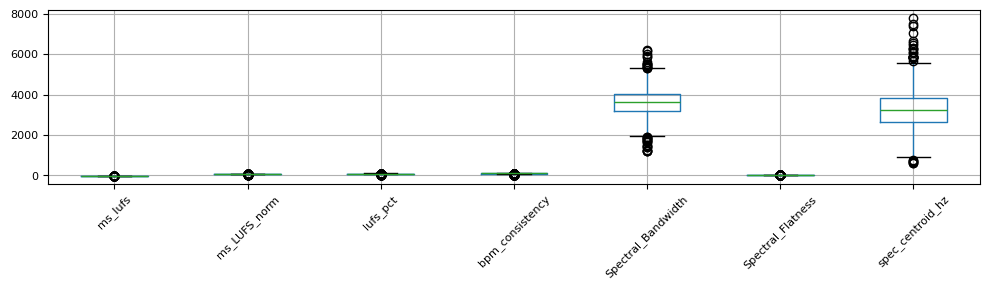

In [34]:
import matplotlib.pyplot as plt

cols_num = [
    'ms_lufs','ms_LUFS_norm','lufs_pct','bpm_consistency',
    'rel_year','Spectral_Bandwidth','Spectral_Flatness','spec_centroid_hz'
]

plt.figure(figsize=(10, 3))  # very thin

df[cols_num].boxplot()

plt.xticks(rotation=45, fontsize=8)
plt.yticks(fontsize=8)

plt.tight_layout()
plt.show()

In [22]:
df.columns.tolist()

['ID',
 'Path',
 'ms_lufs',
 'id_cat_lufs',
 'ms_LUFS_norm',
 'lufs_pct',
 'bpm_consistency',
 'bpm_consistency_cat',
 'genre',
 'rel_year',
 'KEY',
 'key_file',
 'remix',
 'key_dj',
 'key_music',
 'Relative_Key',
 'Key_Up',
 'Key_Down',
 'Jaw_s_Mix',
 'Mood_Shifter',
 'Spectral_Bandwidth',
 'Spectral_Flatness',
 'HEX_shape_texture',
 'spec_centroid_hz',
 'centroid_color',
 'centroid_desc']

# 2 EDA steps 1-6

In [3]:
path_out="reports/tables/eda_summary.csv"
report_eda_1 = eda_01_06_GET_report(df,path_out)


DATA SHAPE: (50000, 7)

COLUMNS: ['age', 'income', 'visits', 'time_on_site', 'region', 'device', 'purchase']

HEAD:
    age        income  visits  time_on_site region   device  purchase
0   56  96637.622495       8      8.103676   west   tablet         1
1   69  58152.382893       1      8.976270   west  desktop         1
2   46  62621.686970       4      5.530083  north   mobile         0
3   32  38626.881816       6      7.138115   east   tablet         0
4   60  61122.896874       4      3.167155   east   tablet         1

TAIL:
        age        income  visits  time_on_site region  device  purchase
49995   66  66922.130108       4      2.240610   east  tablet         0
49996   35  73402.084080       6      9.932969   east  mobile         1
49997   28  33997.022248       5      6.596355  north  mobile         0
49998   59  53357.004790      10      8.450253   east  tablet         0
49999   35  78511.695536       6      5.496114  south  mobile         0

DATA INFO:
<class 'pandas.c

# Preprocess data , x , y variable 

In [4]:
X, y = prep_features_target(df)


FEATURE MATRIX: (50000, 9)
TARGET: (50000,)


# model Preparation 

In [5]:
X_train, X_test, y_train, y_test = split_train_test(X, y)


TRAIN: (40000, 9)
TEST: (10000, 9)
